In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/mit-bih/mitbih_train.csv",
    header=None
)
test_df = pd.read_csv(
    "/content/drive/MyDrive/mit-bih/mitbih_test.csv",
    header=None
)

187 features

last column target

In [5]:
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

Train Shape: (87554, 188)
Test Shape: (21892, 188)


In [6]:
train_df[187] = train_df[187].astype(int)

Classes: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]

* N : Non-ecotic beats (normal beat)
* S : Supraventricular ectopic beats
* V : Ventricular ectopic beats*  
* F : Fusion Beats
* Q : Unknown Beats

In [7]:
train_df[187]

,187
0,0
1,0
2,0
3,0
4,0
...,...
87549,4
87550,4
87551,4
87552,4


In [8]:
equilibre = train_df[187].value_counts()
print(equilibre)

187
0    72471
4     6431
2     5788
1     2223
3      641
Name: count, dtype: int64


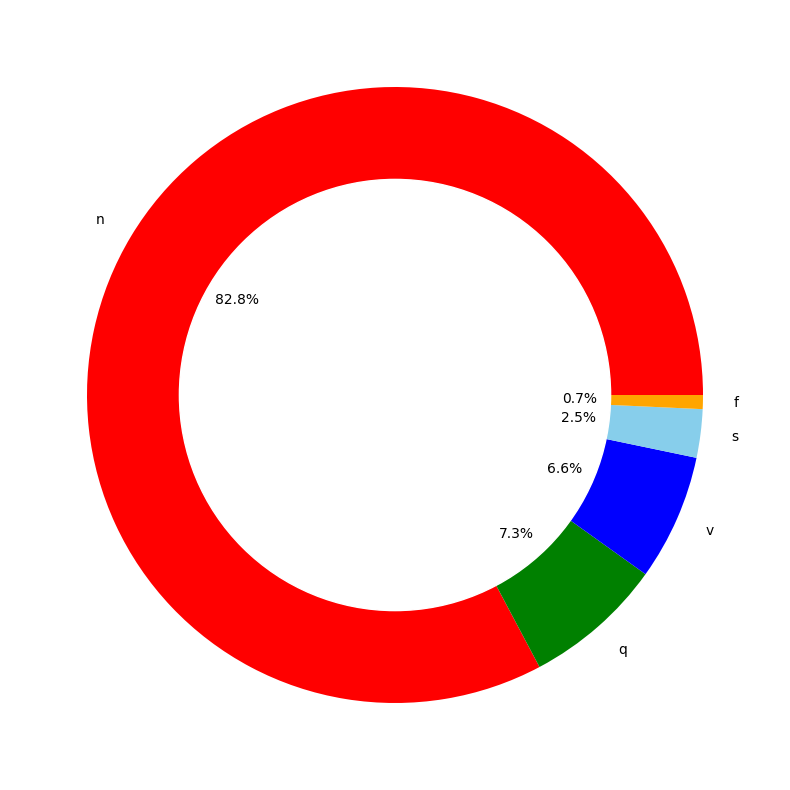

In [9]:
plt.figure(figsize=(20, 10))
my_circle = plt.Circle(
    (0, 0),
    0.7,
    color='white'
)
plt.pie(
    equilibre,
    labels=['n', 'q', 'v', 's', 'f'],
    colors=['red', 'green', 'blue', 'skyblue', 'orange'],
    autopct='%1.1f%%'
)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [10]:
from sklearn.utils import resample

df_1 = train_df[train_df[187] == 1]
df_2 = train_df[train_df[187] == 2]
df_3 = train_df[train_df[187] == 3]
df_4 = train_df[train_df[187] == 4]
df_0 = (train_df[train_df[187] == 0]).sample(n=20000, random_state=42)

df_1_upsample = resample(df_1, replace=True, n_samples=20000, random_state=123)
df_2_upsample = resample(df_2, replace=True, n_samples=20000, random_state=124)
df_3_upsample = resample(df_3, replace=True, n_samples=20000, random_state=125)
df_4_upsample = resample(df_4, replace=True, n_samples=20000, random_state=126)

train_df = pd.concat([df_0, df_1_upsample, df_2_upsample, df_3_upsample, df_4_upsample])

In [11]:
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

Train Shape: (100000, 188)
Test Shape: (21892, 188)


In [12]:
equilibre = train_df[187].value_counts()
print(equilibre)

187
0    20000
1    20000
2    20000
3    20000
4    20000
Name: count, dtype: int64


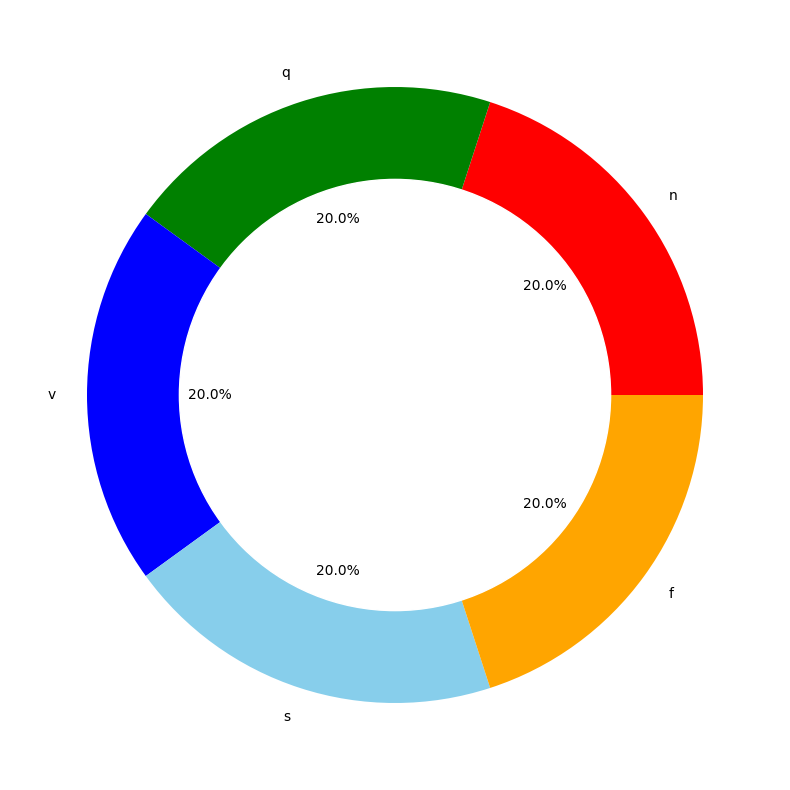

In [13]:
plt.figure(figsize=(20, 10))
my_circle = plt.Circle(
    (0, 0),
    0.7,
    color='white'
)
plt.pie(
    equilibre,
    labels=['n', 'q', 'v', 's', 'f'],
    colors=['red', 'green', 'blue', 'skyblue', 'orange'],
    autopct='%1.1f%%'
)
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [14]:
c = train_df.groupby(187, group_keys=False).apply(
    lambda tdf: tdf.sample(1),
    include_groups=False
)

In [15]:
def add_gaussian_noise(signal):
    noise = np.random.normal(0, 0.05, 186)
    return signal + noise

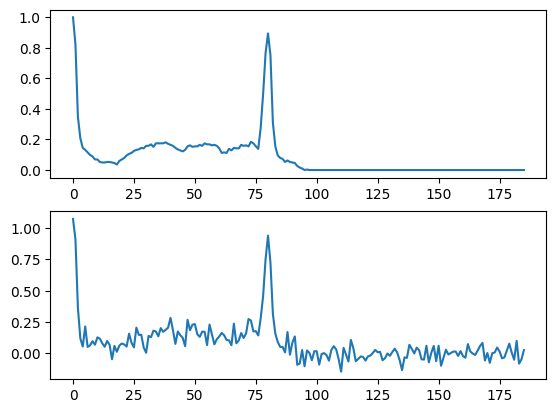

In [16]:
tempo = c.iloc[0, :186]
bruited = add_gaussian_noise(tempo)

plt.subplot(2, 1, 1)
plt.plot(c.iloc[0, :186])

plt.subplot(2, 1, 2)
plt.plot(bruited)

plt.show()

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [18]:
y_train_tensor = torch.tensor(train_df[187].values, dtype=torch.long)
y_test_tensor = torch.tensor(test_df[187].values, dtype=torch.long)

In [19]:
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"y_test tensor shape: {y_test_tensor.shape}")

y_train_tensor shape: torch.Size([100000])
y_test tensor shape: torch.Size([21892])


In [20]:
X_train = train_df.iloc[:, :186].values
X_test = test_df.iloc[:, :186].values

for i in range(len(X_train)):
    X_train[i] = add_gaussian_noise(X_train[i])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)

In [21]:
print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")

X_train_tensor shape: torch.Size([100000, 1, 186])
X_test_tensor shape: torch.Size([21892, 1, 186])


In [22]:
train_ds = TensorDataset(X_train_tensor, y_train_tensor.long())
test_ds = TensorDataset(X_test_tensor, y_test_tensor.long())

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

In [24]:
class ECGNet(nn.Module):

    def __init__(self):
        super(ECGNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 186 -> 93

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 93 -> 46

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # Global Average Pooling
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [25]:
model = ECGNet().to(device)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [27]:
def train(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [28]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [29]:
epochs = 20
for epoch in range(epochs):
    tr_loss, tr_acc = train(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)
    scheduler.step(te_loss)
    print(f"Epoch {epoch + 1:02d} | Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
          f"Test Loss: {te_loss:.4f}, Acc: {te_acc:.4f}")

Epoch 01 | Train Loss: 0.5534, Acc: 0.7983 | Test Loss: 0.4743, Acc: 0.8457
Epoch 02 | Train Loss: 0.3786, Acc: 0.8625 | Test Loss: 0.3656, Acc: 0.8994
Epoch 03 | Train Loss: 0.3289, Acc: 0.8802 | Test Loss: 0.4188, Acc: 0.8476
Epoch 04 | Train Loss: 0.2950, Acc: 0.8911 | Test Loss: 0.3315, Acc: 0.8864
Epoch 05 | Train Loss: 0.2736, Acc: 0.8986 | Test Loss: 0.3537, Acc: 0.8767
Epoch 06 | Train Loss: 0.2549, Acc: 0.9053 | Test Loss: 0.4637, Acc: 0.8310
Epoch 07 | Train Loss: 0.2410, Acc: 0.9101 | Test Loss: 0.2701, Acc: 0.9053
Epoch 08 | Train Loss: 0.2321, Acc: 0.9136 | Test Loss: 0.3936, Acc: 0.8483
Epoch 09 | Train Loss: 0.2214, Acc: 0.9174 | Test Loss: 0.3023, Acc: 0.8959
Epoch 10 | Train Loss: 0.2140, Acc: 0.9195 | Test Loss: 0.3990, Acc: 0.8424
Epoch 11 | Train Loss: 0.2082, Acc: 0.9209 | Test Loss: 0.2339, Acc: 0.9238
Epoch 12 | Train Loss: 0.2015, Acc: 0.9246 | Test Loss: 0.2384, Acc: 0.9161
Epoch 13 | Train Loss: 0.1949, Acc: 0.9270 | Test Loss: 0.2919, Acc: 0.9006
Epoch 14 | T

In [31]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=[f"Class {i}" for i in range(5)])
)

              precision    recall  f1-score   support

     Class 0       0.99      0.89      0.94     18118
     Class 1       0.26      0.83      0.39       556
     Class 2       0.87      0.95      0.91      1448
     Class 3       0.27      0.93      0.42       162
     Class 4       0.96      0.99      0.97      1608

    accuracy                           0.90     21892
   macro avg       0.67      0.92      0.73     21892
weighted avg       0.96      0.90      0.92     21892



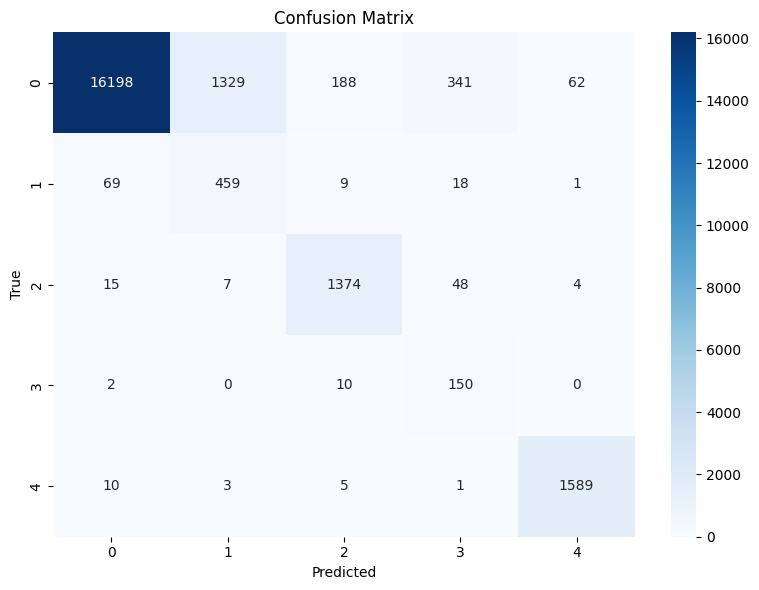

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(5),
    yticklabels=range(5)
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [35]:
torch.save(model.state_dict(), 'ecgnet.pth')